In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm

In [2]:
def Suceptibility_by_Level(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    OLS_slope, OLS_intercept = xr.apply_ufunc(
        Function.OLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    ODR_slope, ODR_intercept = xr.apply_ufunc(
        Function.TLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    Deming_slope, Deming_intercept = xr.apply_ufunc(
        Function.deming_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    PCA_slope, PCA_intercept = xr.apply_ufunc(
        Function.PCA_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )

    ds_out = xr.Dataset(
        data_vars={
            'OLS slope': (('radius', 'lev'), OLS_slope.data),
            'OLS intercept': (('radius', 'lev'), OLS_intercept.data),
            'ODR slope': (('radius', 'lev'), ODR_slope.data),
            'ODR intercept': (('radius', 'lev'), ODR_intercept.data),
            'Deming slope': (('radius', 'lev'), Deming_slope.data),
            'Deming intercept': (('radius', 'lev'), Deming_intercept.data),
            'PCA slope': (('radius', 'lev'), PCA_slope.data),
            'PCA intercept': (('radius', 'lev'), PCA_intercept.data),

        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,

        }
    )
    ds_out2 = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out, ds_out2


In [3]:
def compute_allLev(CCN_ds, CDNC_da):
    """
    Compute OLS and TLS slope/intercept per radius,
    flattening across all levels and times.
    Returns a Dataset with variables: slope_OLS, intercept_OLS, slope_TLS, intercept_TLS
    """
    # Align CCN and CDNC over lev and time
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    # Broadcast CDNC to match CCN dimensions
    CDNC_broadcast = CDNC_aligned.broadcast_like(CCN_aligned)

    # --- OLS ---
    slope_OLS, intercept_OLS = xr.apply_ufunc(
        Function.OLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )

    # --- TLS ---
    slope_TLS, intercept_TLS = xr.apply_ufunc(
        Function.TLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    
    # --- Deming ---
    slope_Deming, intercept_Deming = xr.apply_ufunc(
        Function.deming_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    # --- PCA ---
    slope_PCA, intercept_PCA = xr.apply_ufunc(
        Function.PCA_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )


    # Package into dataset
    ds_out = xr.Dataset(
        data_vars={
            'All_Level_OLS_slope': (('radius',), slope_OLS.data),
            'All_Level_OLS_intercept': (('radius',), intercept_OLS.data),
            'All_Level_TLS_slope': (('radius',), slope_TLS.data),
            'All_Level_TLS_intercept': (('radius',), intercept_TLS.data),
            'All_Level_Deming_slope': (('radius',), slope_Deming.data),
            'All_Level_Deming_intercept': (('radius',), intercept_Deming.data),
            'All_Level_PCA_slope': (('radius',), slope_PCA.data),
            'All_Level_PCA_intercept': (('radius',), intercept_PCA.data),

        },
        coords={
            'radius': CCN_aligned.radius,

        }
    )

    return ds_out

In [25]:
def compute_R2_allLev(CCN_ds, CDNC_da):
    """
    Compute coefficient of determination (R²),
    flattening across all levels and times.
    Returns a Dataset with variable: R2
    """

    # Align CCN and CDNC over lev and time
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    # Broadcast CDNC to match CCN dimensions
    CDNC_broadcast = CDNC_aligned.broadcast_like(CCN_aligned)

    # Correlation over lev and time, preserving radius
    R = xr.corr(
        CCN_aligned,
        CDNC_broadcast,
        dim=("lev", "time")
    )

    # Coefficient of determination
    R2 = R ** 2

    # Package into dataset
    ds_out = xr.Dataset(
        data_vars={
            "R2": (("radius",), R2.data),
        },
        coords={
            "radius": CCN_aligned.radius,
        }
    )

    return ds_out


In [13]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
#radii = np.arange(20,51)
radii = np.linspace(20, 500, 31)
VarList = ['FREQL', 'Z3']
x = xr.DataArray(np.logspace(-0.5,6, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,6, num=200)})

In [5]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:             (time: 8761, station: 15, lev: 32, ilev: 33)
Coordinates:
  * time                (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
  * station             (station) <U8 480B 'ZEP' 'SMR-II' ... 'Izana' 'Maldives'
  * lev                 (lev) float64 256B 3.643 7.595 14.36 ... 976.3 992.6
  * ilev                (ilev) float64 264B 2.255 5.032 10.16 ... 985.1 1e+03
Data variables: (12/275)
    ABSVIS              (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ACTNI               (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ACTNL               (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ACTREI              (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ACTREL              (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    AOD_VIS             (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ...                  ...
    isoprene            (station, time, lev) float32 17MB dask.array<chunksize=(15, 8761, 32), meta=np.ndarray>
    monoterp            (station, time, lev) float32 17MB dask.array<chunksize=(15, 8761, 32), meta=np.ndarray>
    TOT_ICLD_VISTAU_s   (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    TOT_CLD_VISTAU_s    (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    optical_depth       (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    transmittance       (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>

In [14]:
all_stations = []
all_stationsCCN = []
all_stationsHeight = []
for station in stations:
    Nor_ds = Function.NorESMExtract_Dask(NorPath, station, VarList, x, PNSD=False)
    CCN_ds = Function.NorERF(Nor_ds, radii)
    height = Nor_ds['Z3'].mean('time')
    ## Mask when cloud coverage is above 80%
    Level_susc_ds, Levels_CCN_ds = Suceptibility_by_Level(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL']>0.8))
    Susceptibility_AllLevs = compute_allLev(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL']>0.8))
    Susceptibility_ds = xr.merge([Level_susc_ds, Susceptibility_AllLevs])
    
    all_stations.append(Susceptibility_ds.assign_coords(station=station))
    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))
    all_stationsHeight.append(height.assign_coords(station=station))
# Concatenate across stations
Susceptibility_all = xr.concat(all_stations, dim='station')
CCN_all = xr.concat(all_stationsCCN, dim='station')
Height_all = xr.concat(all_stationsHeight, dim='station')

Susceptibility_all = Susceptibility_all.compute()
CCN_all = CCN_all.compute()

In [31]:
CCN_all

<xarray.Dataset> Size: 1GB
Dimensions:  (station: 15, radius: 31, time: 8761, lev: 32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
  * station  (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * radius   (radius) float64 248B 20.0 36.0 52.0 68.0 ... 468.0 484.0 500.0
Data variables:
    CCN      (station, radius, time, lev) float64 1GB 0.1202 0.2275 ... 0.8674
    CDNC     (station, time, lev) float32 17MB nan nan nan nan ... nan nan nan

In [50]:
R2_list = []
for r in radii:
    

    R = xr.corr(
        CCN_all['CCN'].sel(radius = r, station = 'SMR-II'),
        CCN_all['CDNC'].sel(station = 'SMR-II'),
        dim=("lev", "time")
    )
    
    R2=R**2
    R2_list.append(R2)

R2_all = xr.concat(R2_list, dim = 'radius')

In [51]:
R2_all

<xarray.DataArray (radius: 31)> Size: 248B
array([0.03760127, 0.07486881, 0.19746268, 0.31427737, 0.33919107,
       0.32710426, 0.30399913, 0.27397529, 0.23876387, 0.20170651,
       0.1669419 , 0.13796429, 0.11645909, 0.0984244 , 0.08429976,
       0.07366199, 0.06566399, 0.05963099, 0.05504537, 0.05152001,
       0.04877246, 0.04659572, 0.04483621, 0.04337806, 0.04213213,
       0.04102851, 0.04001149, 0.03903621, 0.03806674, 0.03707491,
       0.03603978])
Coordinates:
    station  <U8 32B 'SMR-II'
  * radius   (radius) float64 248B 20.0 36.0 52.0 68.0 ... 468.0 484.0 500.0

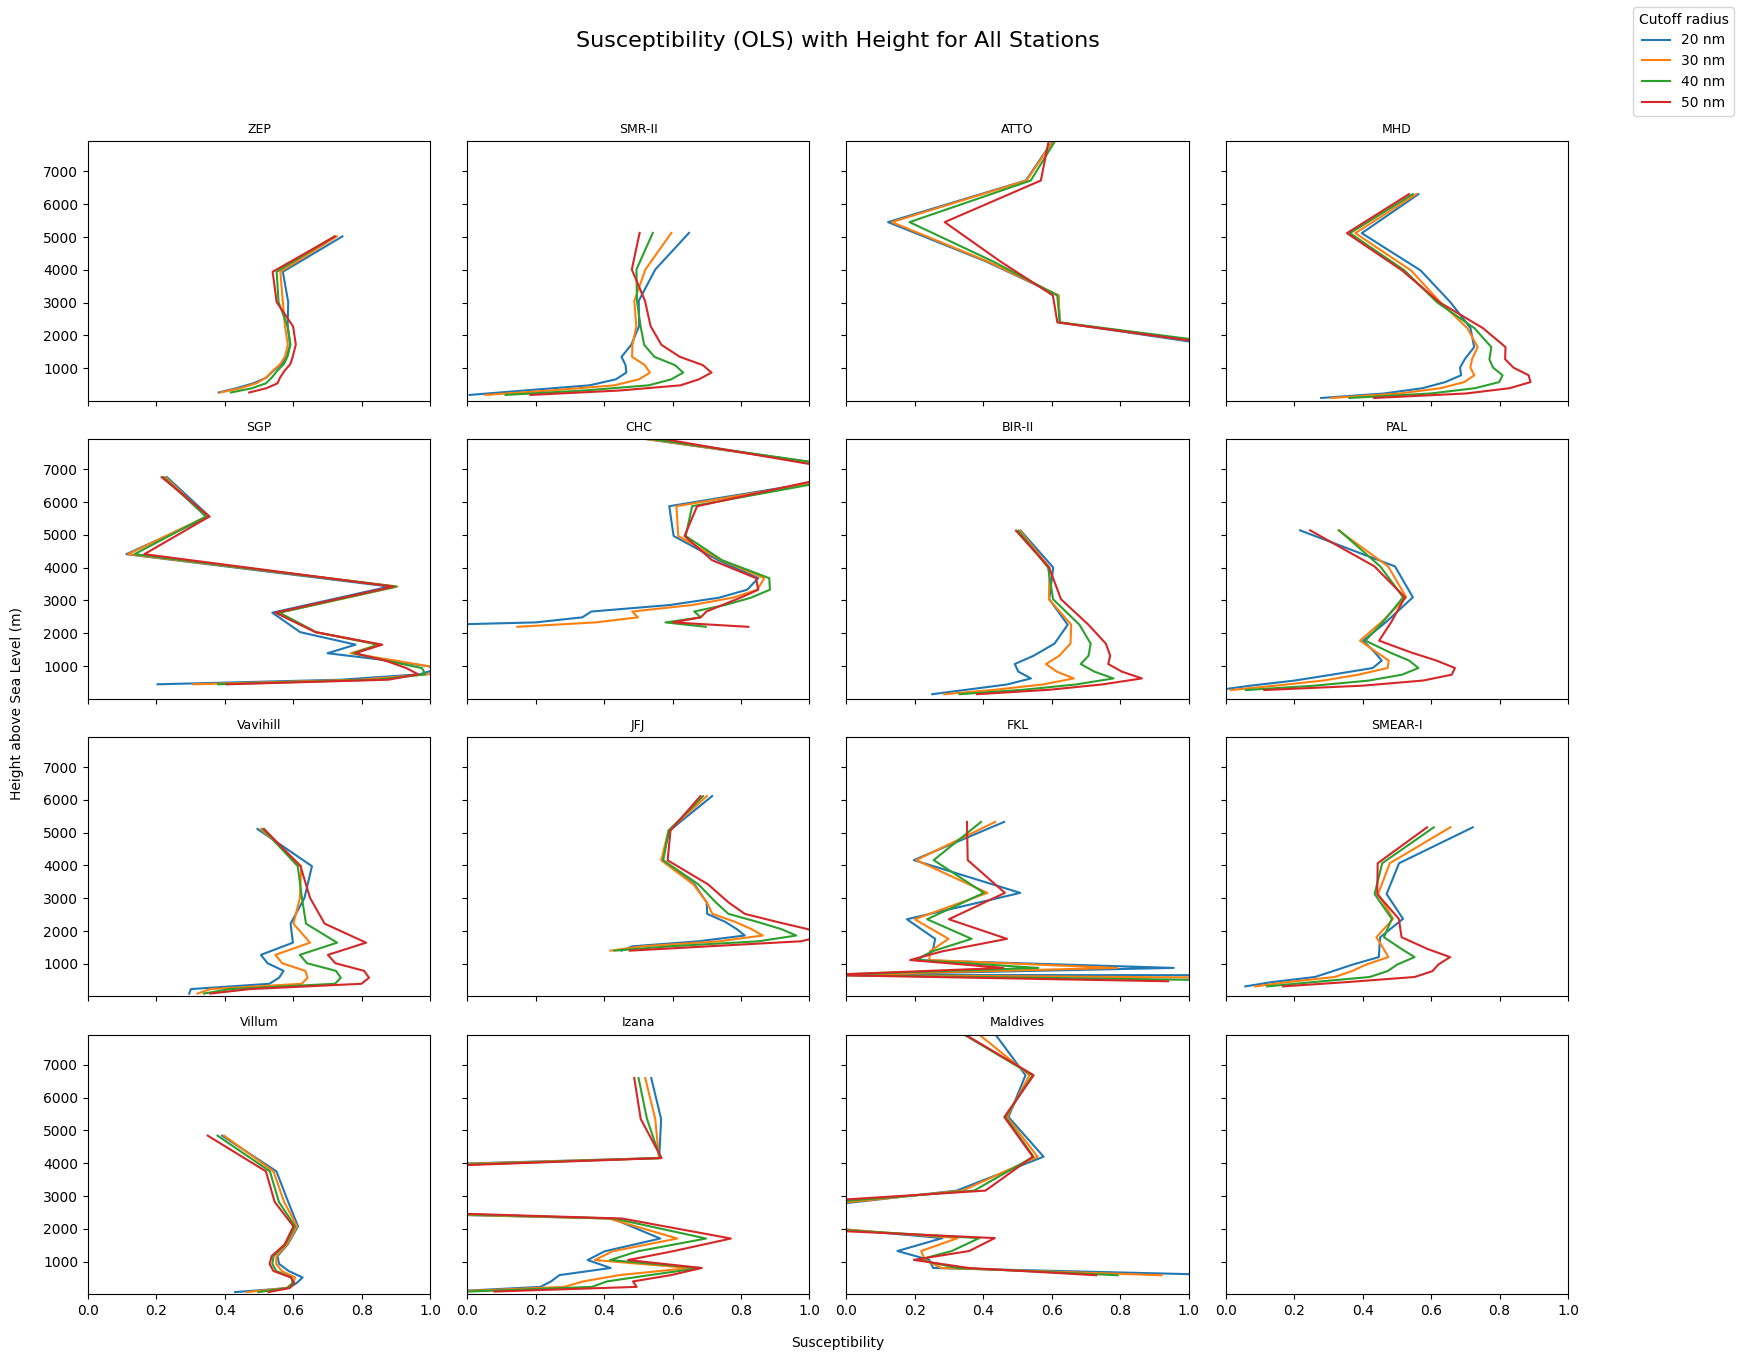

In [7]:
def SubPlotSusc_by_Level(ax, ds=Susceptibility_all, Fit='OLS', station='SMR-II'):
    radii_to_plot = [20, 30, 40, 50]

    yvals = Height_all.sel(station=station)

    for r in radii_to_plot:
        xvals = ds[f'{Fit} slope'].sel(radius=r, station=station)
        ax.plot(xvals, yvals, label=f'{r} nm')

    # Axis limits
    Max = float(
        Height_all.sel(station=station)
        .where(ds[f'{Fit} slope'].sel(radius=r, station=station) > 0)
        .max()
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(1, Max)

    ax.set_title(station, fontsize=9)

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(18, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, station in zip(axes, stations):
    SubPlotSusc_by_Level(
        ax,
        Susceptibility_all,
        Fit='OLS',
        station=station
    )
    # Global axis labels
fig.text(0.5, 0.04, "Susceptibility", ha='center')
fig.text(0.04, 0.5, "Height above Sea Level (m)", va='center', rotation='vertical')

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Cutoff radius", loc="upper right")

fig.suptitle(
    "Susceptibility (OLS) with Height for All Stations",
    fontsize=16
)

fig.tight_layout(rect=[0.05, 0.05, 0.92, 0.95])
plt.show()

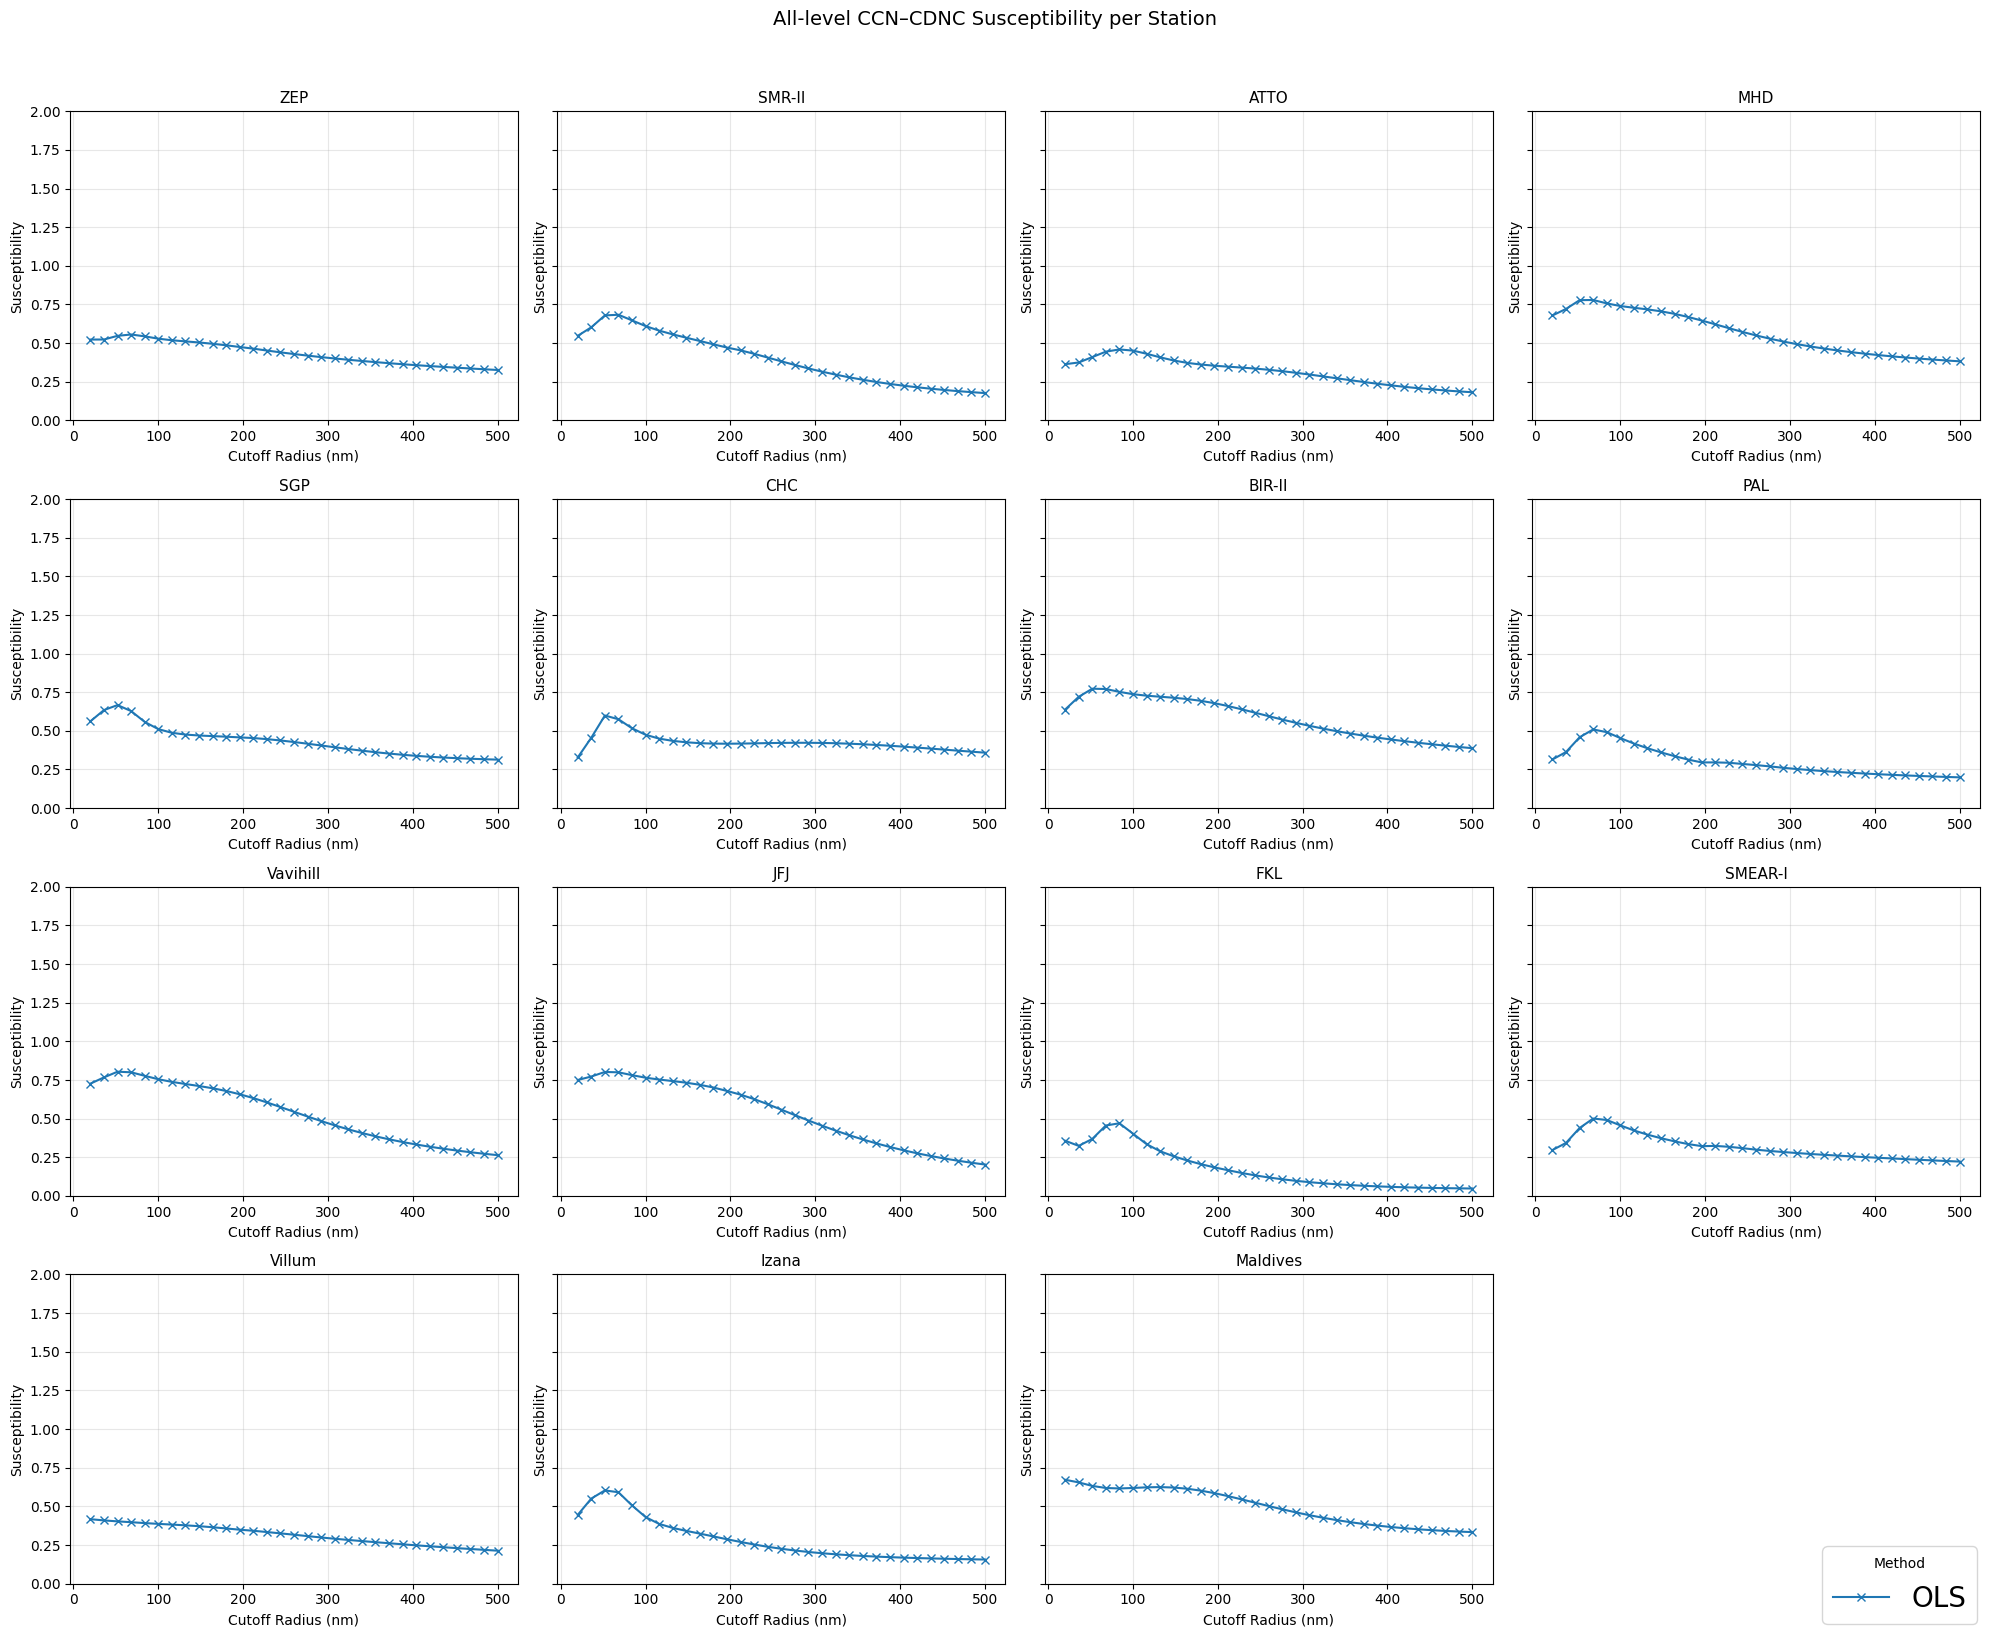

In [16]:
stations = Susceptibility_all.station.values
methods = ["OLS"]

# Define number of columns and rows dynamically
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    for method in methods:
        var_name = f"All_Level_{method}_slope"
        if var_name in Susceptibility_all:
            Susceptibility_all[var_name].sel(station=station).plot(
                ax=ax, marker='x', label=method
            )
    ax.set_title(f"{station}", fontsize=11)
    ax.set_xlabel("Cutoff Radius (nm)")
    ax.set_ylabel("Susceptibility")
    ax.set_ylim(0, 2)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(stations), len(axes)):
    axes[j].set_visible(False)

# Add a global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc="lower right", fontsize=20)

fig.suptitle("All-level CCN–CDNC Susceptibility per Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


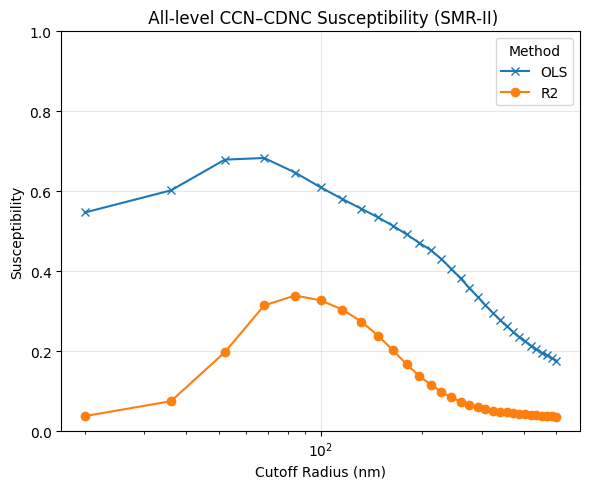

In [54]:
methods = ["OLS"]

fig, ax = plt.subplots(figsize=(6, 5))

for method in methods:
    var_name = f"All_Level_{method}_slope"
    if var_name in Susceptibility_all:
        SMRII_data = Susceptibility_all[var_name].sel(station = 'SMR-II')
        SMRII_data.plot(
            ax=ax,
            marker='x',
            label=method
        )
R2_all.plot(            
    ax=ax,
    marker='o',
    label = 'R2'
)
ax.set_title(" All-level CCN–CDNC Susceptibility (SMR-II)", fontsize=12)
ax.set_xlabel("Cutoff Radius (nm)")
ax.set_ylabel("Susceptibility")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(title="Method")
ax.set_xscale('log')
plt.tight_layout()
plt.show()

In [9]:
def plot_station_fits_from_dataset(Susceptibility_all, station, CCN_ds, Nor_ds, radius=35, methods=None):
    """
    Plot Nd vs CCN (log–log) with precomputed fits from Susceptibility_all.
    No refitting is done here.
    """
    if methods is None:
        methods = ["OLS", "TLS", "Deming", "PCA"]

    # --- Prepare data ---
    x = CCN_all['CCN'].sel(radius=radius, station = station).to_numpy().ravel()
    y = CCN_all["CDNC"].sel(station = station).to_numpy().ravel()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    fits = []

    # --- Get slopes/intercepts from dataset ---
    for method in methods:
        slope_var = f"All_Level_{method}_slope"
        intercept_var = f"All_Level_{method}_intercept"

        if slope_var in Susceptibility_all and intercept_var in Susceptibility_all:
            slope = Susceptibility_all[slope_var].sel(station=station, radius=radius).compute().item()
            intercept = Susceptibility_all[intercept_var].sel(station=station, radius=radius).compute().item()

            fits.append({
                "slope": slope,
                "intercept": intercept,
                "label": f"{method}: slope={slope:.2f}",
                "style": {
                    "OLS": "r-",
                    "TLS": "g--",
                    "Deming": "b-.",
                    "PCA": "m:",
                }.get(method, "k-")
            })

    # --- Plot all fits on a single hexbin plot ---
    fig, ax = Function.plot_hexbin_regression_multi(
        x, y,
        fits=fits,
        lims=(1, 1e4),
        title=f"{station}: CCN–CDNC Fits (radius={radius} nm)"
    )

    plt.tight_layout()
    return fig, ax

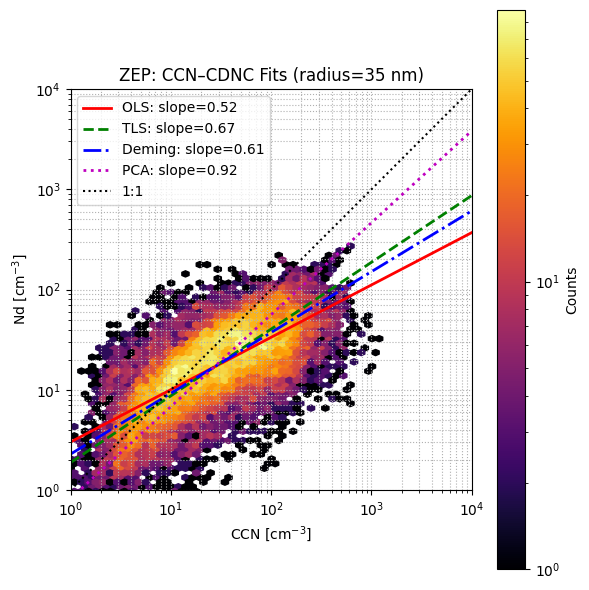

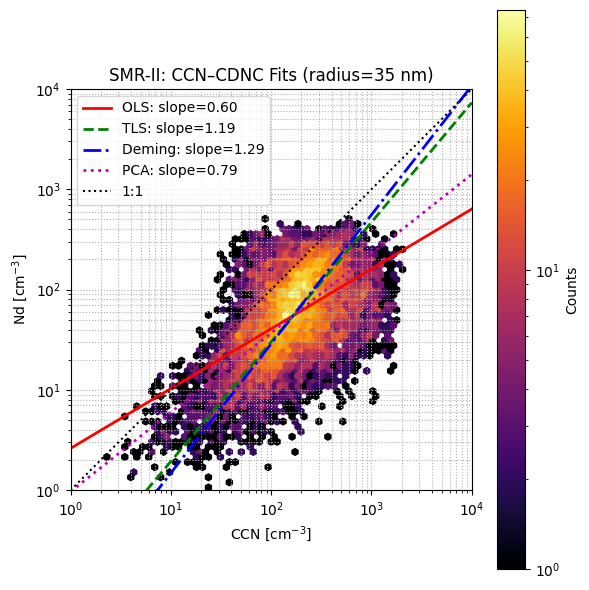

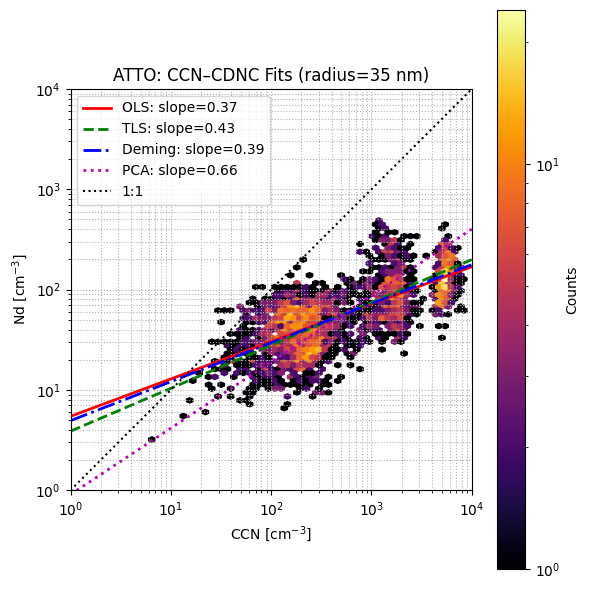

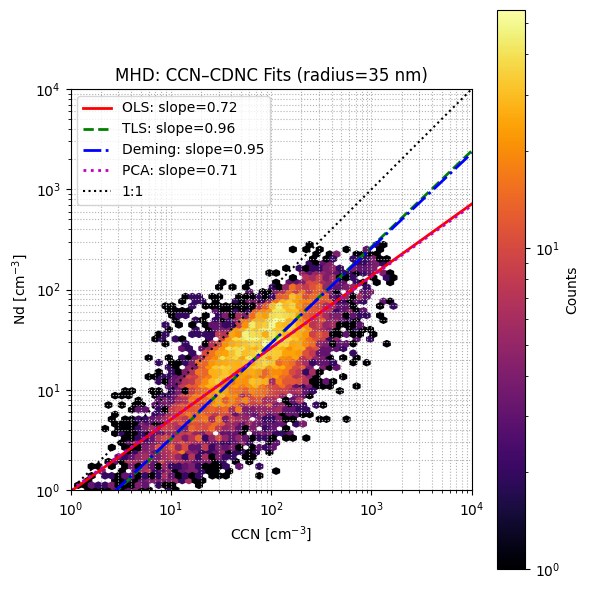

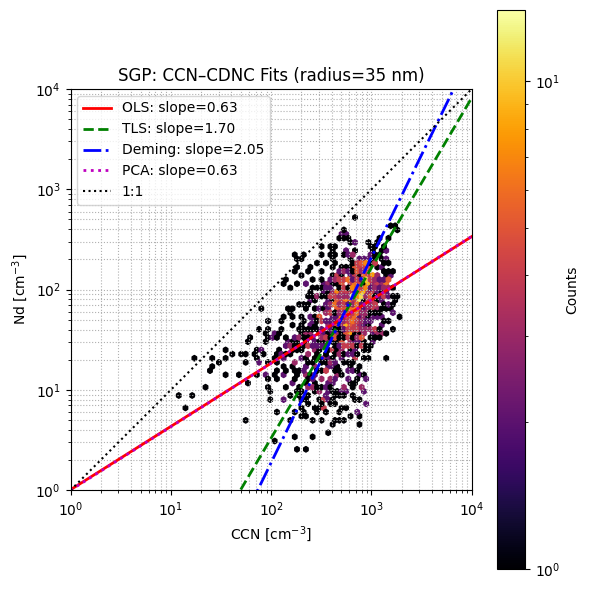

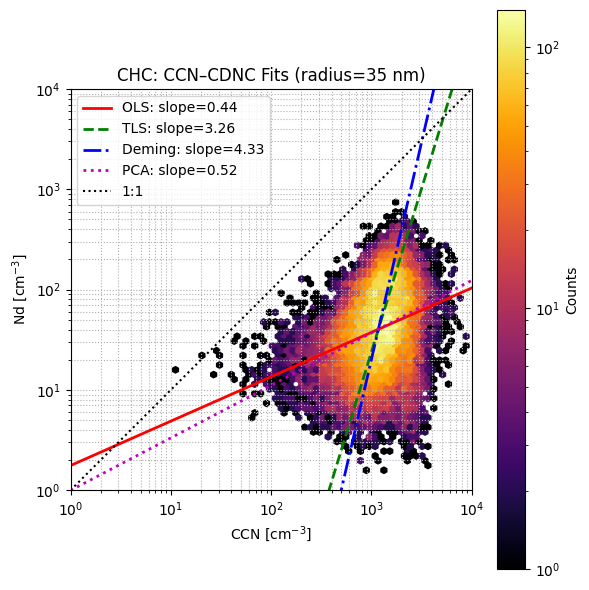

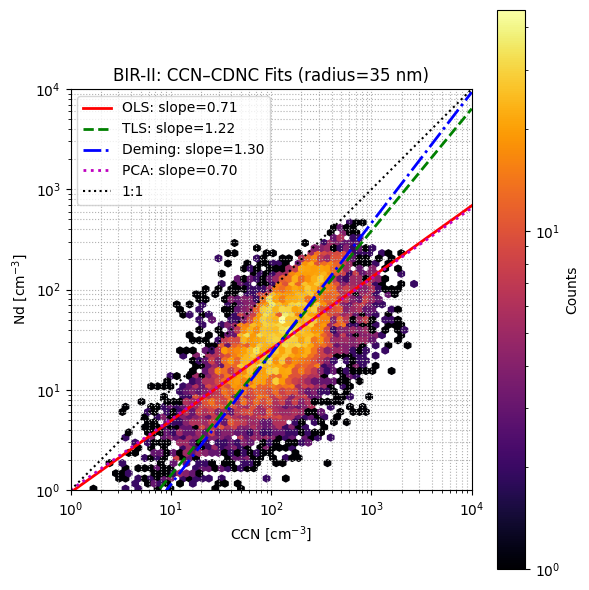

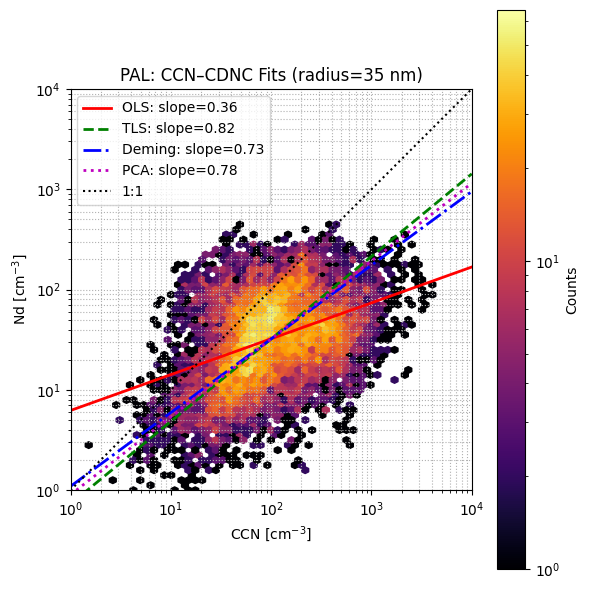

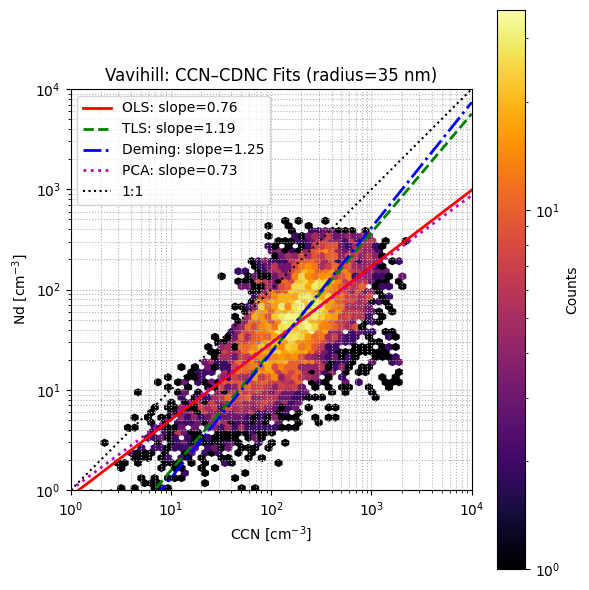

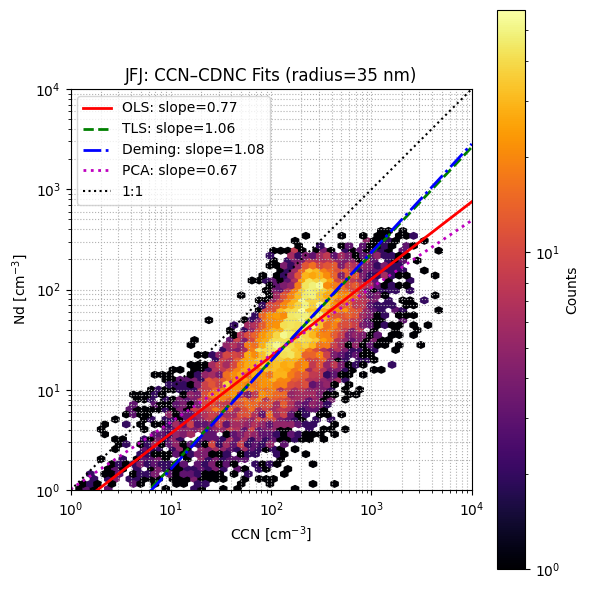

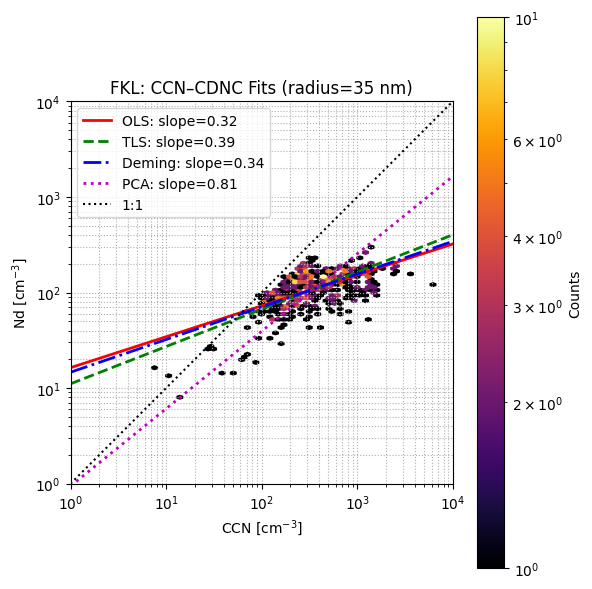

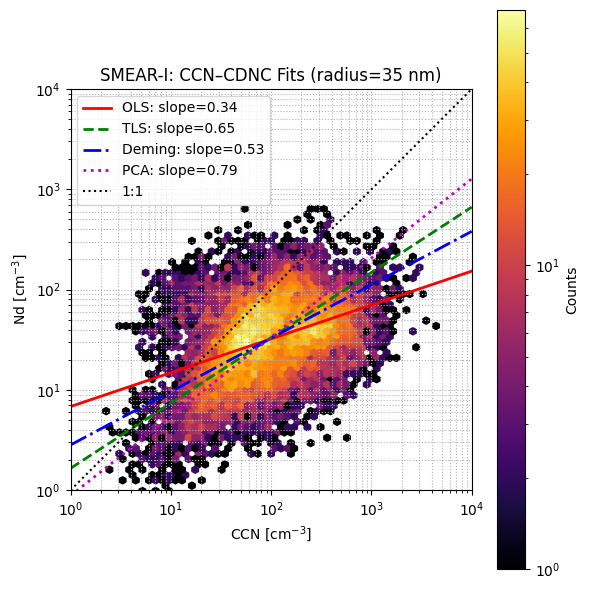

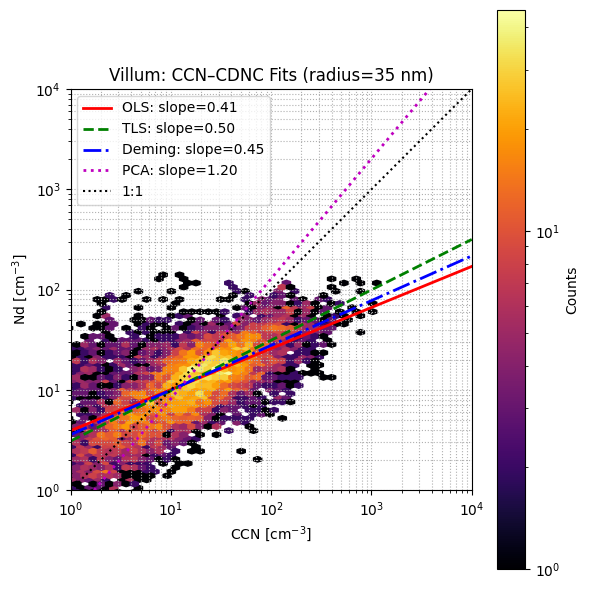

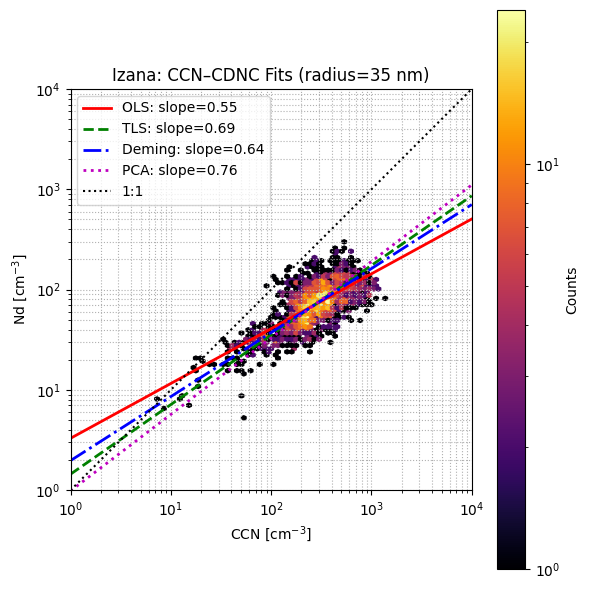

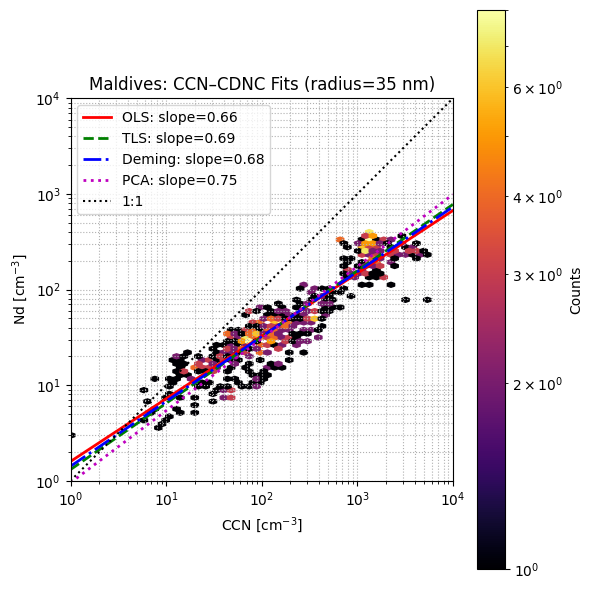

In [10]:
for station in stations:
    plot_station_fits_from_dataset(
        Susceptibility_all,
        station=station,
        CCN_ds=CCN_ds,
        Nor_ds=Nor_ds,
        radius=35
    )

In [11]:
Susceptibility_all

<xarray.Dataset> Size: 983kB
Dimensions:                     (station: 15, radius: 31, lev: 32)
Coordinates:
  * station                     (station) <U8 480B 'ZEP' 'SMR-II' ... 'Maldives'
  * radius                      (radius) int64 248B 20 21 22 23 ... 47 48 49 50
  * lev                         (lev) float64 256B 3.643 7.595 ... 976.3 992.6
Data variables: (12/16)
    OLS slope                   (station, radius, lev) float64 119kB nan ... nan
    OLS intercept               (station, radius, lev) float64 119kB nan ... nan
    ODR slope                   (station, radius, lev) float64 119kB nan ... nan
    ODR intercept               (station, radius, lev) float64 119kB nan ... nan
    Deming slope                (station, radius, lev) float64 119kB nan ... nan
    Deming intercept            (station, radius, lev) float64 119kB nan ... nan
    ...                          ...
    All_Level_TLS_slope         (station, radius) float64 4kB 0.693 ... 0.6634
    All_Level_TLS_intercept     (station, radius) float64 4kB 0.06092 ... 0.3819
    All_Level_Deming_slope      (station, radius) float64 4kB 0.6295 ... 0.6502
    All_Level_Deming_intercept  (station, radius) float64 4kB 0.1677 ... 0.408
    All_Level_PCA_slope         (station, radius) float64 4kB 0.7519 ... 0.8904
    All_Level_PCA_intercept     (station, radius) float64 4kB -0.03804 ... -0...